# snRNAseq comparisons
- Compare across our and Macosko data
- So far, for QC purposes

In [1]:
# load packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# snRNAseq
import anndata as ad
import scanpy as sc


In [2]:
# load data

# Banerjee EI01 (failed dataset)
ei01_mm = sc.read_h5ad("/Users/eisko/data/Banerjee_EI01/Banerjee_EI01_MM.h5ad")
ei01_st = sc.read_h5ad("/Users/eisko/data/Banerjee_EI01/Banerjee_EI01_ST.h5ad")


# Banerjee EI02 (successful dataset)
ei02_mm = sc.read_10x_h5("/Users/eisko/data/Banerjee_EI02/Banerjee_EI02_MM_filtered_bc_matrix.h5")

# Macosko MOp-A data
macosko = sc.read_h5ad("/Users/eisko/data/macosko_data/Macosko_MOpA_subset.h5ad")



/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/ann

In [8]:
# label mito/ribo genes in lab mouse adatas

# EI01_mm and EI02_mm
for adata in [ei01_mm, ei02_mm]:
    # Mitochondrial genes
    adata.var["mt"] = adata.var_names.str.startswith("mt-")

    # Ribosomal genes
    adata.var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl"))

    # hemoglobin genes
    adata.var["hb"] = adata.var_names.str.contains("Hb[^spe]")

# macosko

# Mitochondrial genes
macosko.var["mt"] = macosko.var["gene_name"].str.startswith("mt-")

# Ribosomal genes
macosko.var["ribo"] = macosko.var["gene_name"].str.startswith(("Rps", "Rpl"))

# hemoglobin genes
macosko.var["hb"] = macosko.var["gene_name"].str.contains("Hb[^spe]")



In [9]:
# calcualte qc metrics

# lab mouse
for adata in [ei01_mm, ei02_mm, macosko]:
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], inplace=True, log1p=True)

# singing mouse
sc.pp.calculate_qc_metrics(ei01_st, inplace=True, log1p=True)

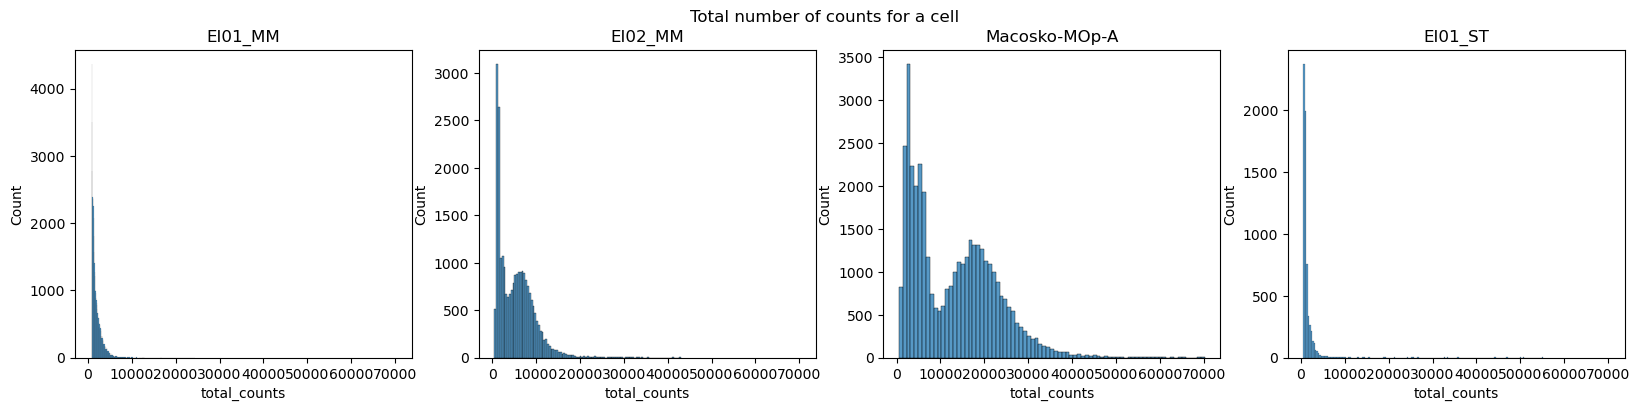

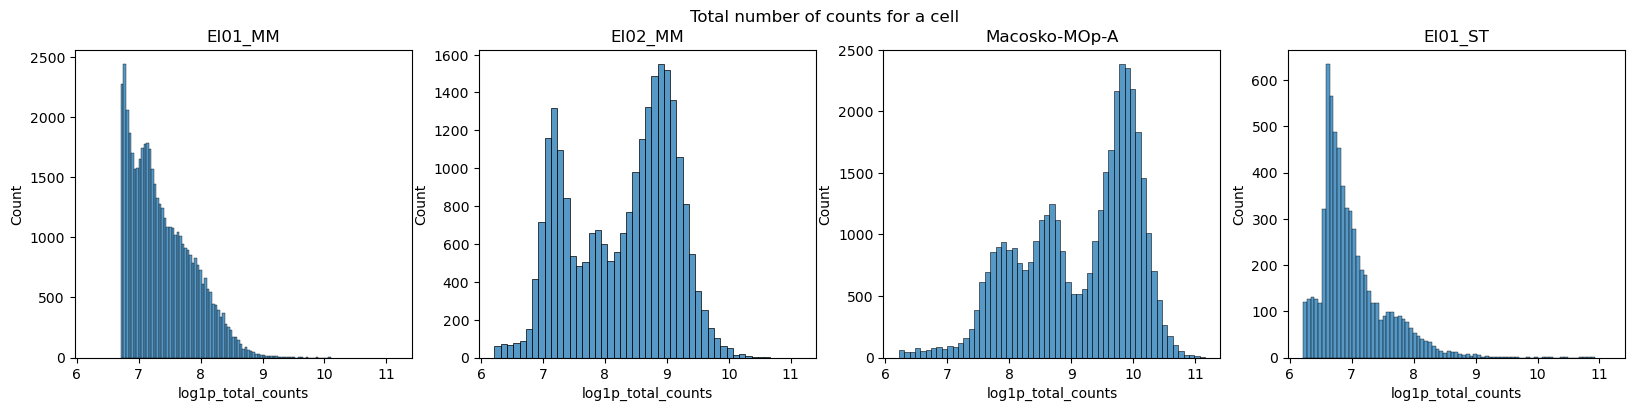

In [47]:
# plot total number of gene counts per cell
datasets = [ei01_mm, ei02_mm, macosko, ei01_st]
labels = ["EI01_MM", "EI02_MM", "Macosko-MOp-A", "EI01_ST"]

fig, axs = plt.subplots(1,4, figsize=(20,4), sharex=True)

for i in range(4):
    ax = axs[i]
    data = datasets[i]
    label = labels[i]
    sns.histplot(data.obs["total_counts"], ax=ax)
    ax.set_title(label)
    # ax.set_xlim(0,70000)

fig.suptitle("Total number of counts for a cell")

plt.show()

fig, axs = plt.subplots(1,4, figsize=(20,4), sharex=True)

for i in range(4):
    ax = axs[i]
    data = datasets[i]
    label = labels[i]
    sns.histplot(data.obs["log1p_total_counts"], ax=ax)
    ax.set_title(label)
    # ax.set_xlim(6,11)

fig.suptitle("Total number of counts for a cell")

plt.show()


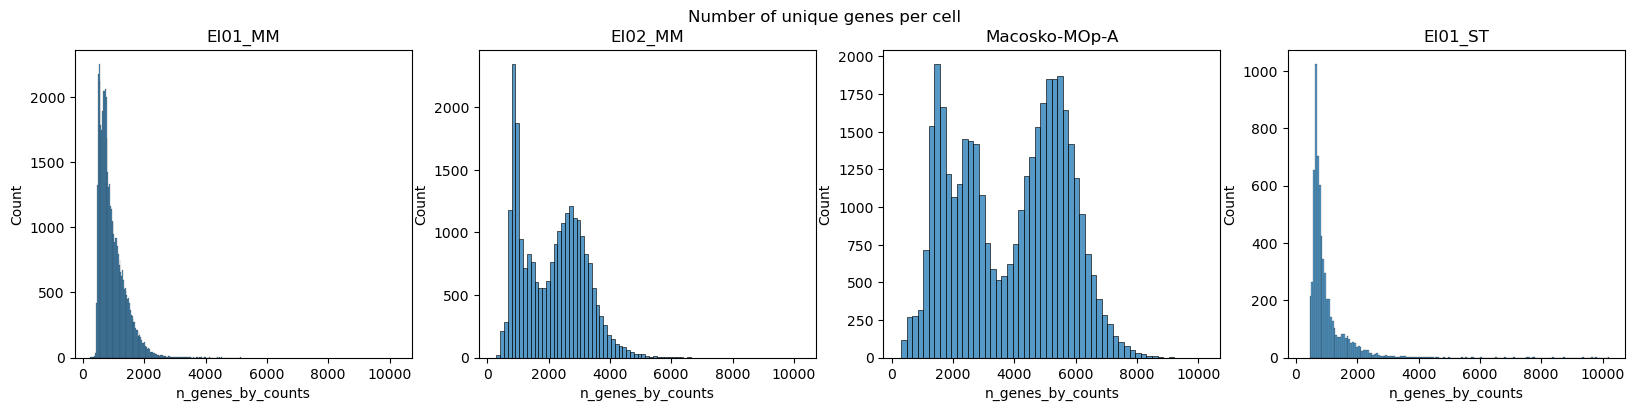

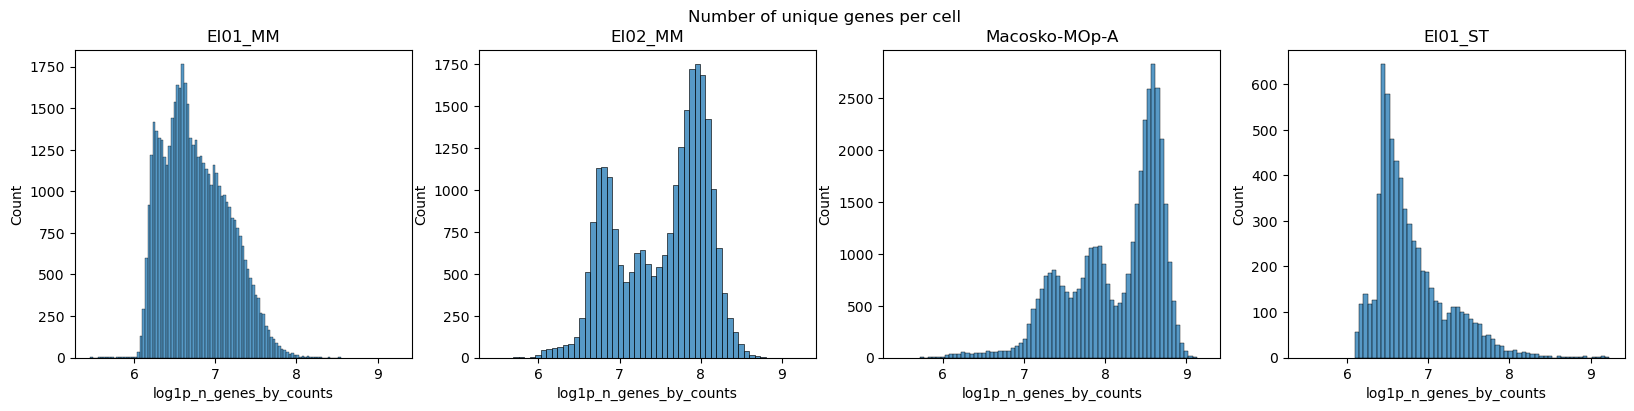

In [48]:
# number of unique genes per cell

fig, axs = plt.subplots(1,4, figsize=(20,4), sharex=True)

for i in range(4):
    ax = axs[i]
    data = datasets[i]
    label = labels[i]
    sns.histplot(data.obs["n_genes_by_counts"], ax=ax)
    ax.set_title(label)
    # ax.set_xlim(0,10000)

fig.suptitle("Number of unique genes per cell")

plt.show()

fig, axs = plt.subplots(1,4, figsize=(20,4), sharex=True)

for i in range(4):
    ax = axs[i]
    data = datasets[i]
    label = labels[i]
    sns.histplot(data.obs["log1p_n_genes_by_counts"], ax=ax)
    ax.set_title(label)
    # ax.set_xlim(5,10)

fig.suptitle("Number of unique genes per cell")

plt.show()

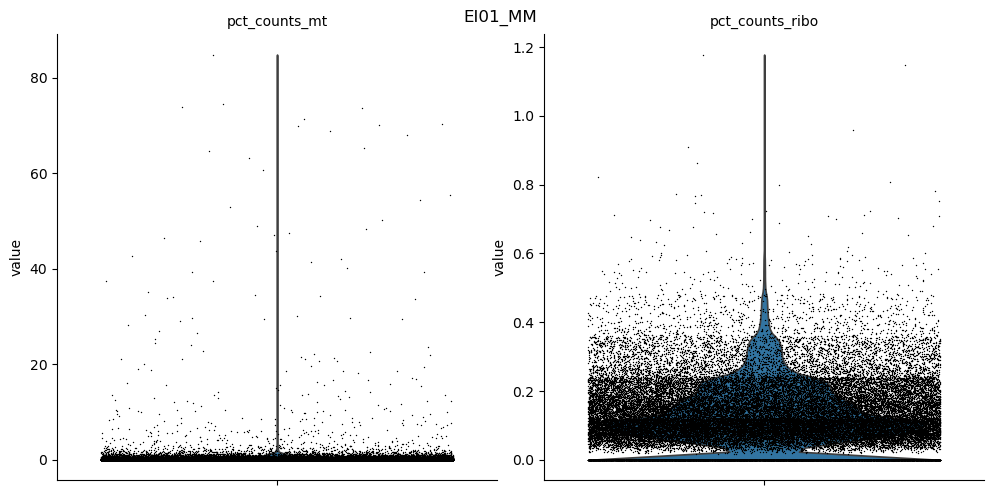

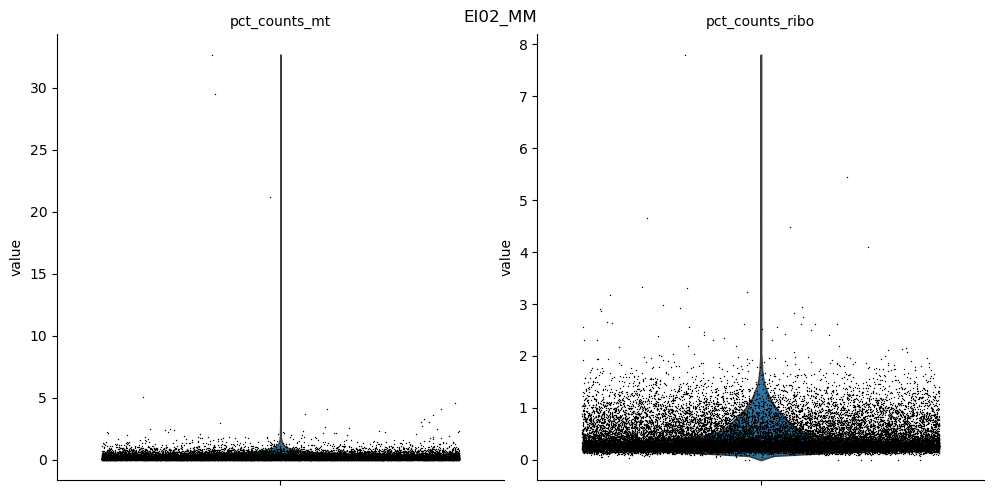

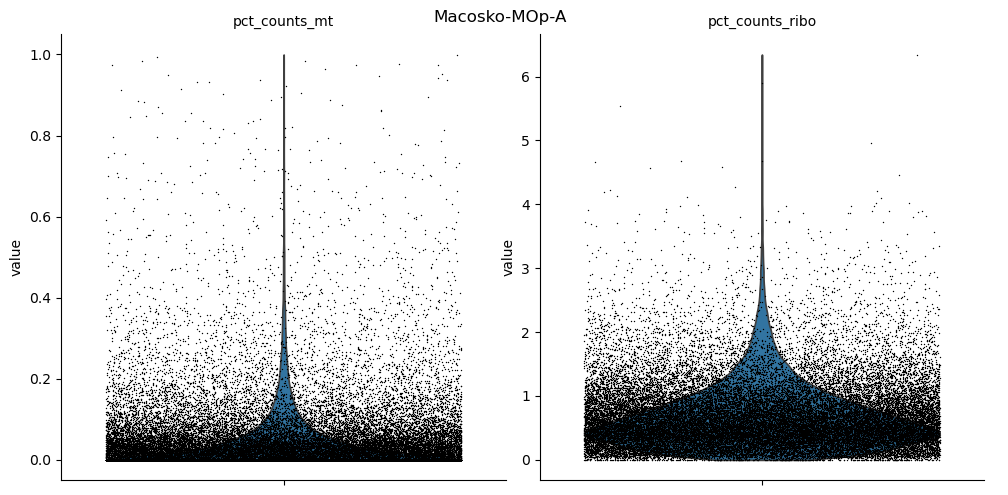

In [37]:
# mito genes
datasets = [ei01_mm, ei02_mm, macosko]
labels = ["EI01_MM", "EI02_MM", "Macosko-MOp-A"]


for i in range(len(datasets)):

    data = datasets[i]
    label = labels[i]
    data.var_names_make_unique()

    g = sc.pl.violin(
        data,
        ["pct_counts_mt", "pct_counts_ribo"],
        jitter=0.4,
        multi_panel=True,
        show=False,
        ax=None
    )
    g.fig.suptitle(label)
    plt.show()

In [40]:
ei01_mm

AnnData object with n_obs × n_vars = 49479 × 32285
    obs: 'sample', 'species', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

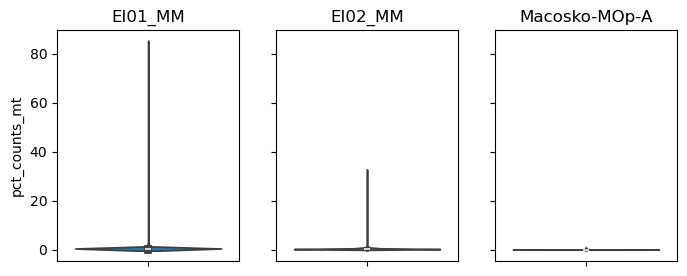

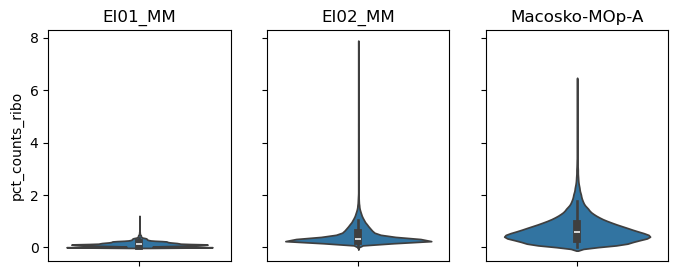

In [50]:
# mito graphs
datasets = [ei01_mm, ei02_mm, macosko]
labels = ["EI01_MM", "EI02_MM", "Macosko-MOp-A"]

fig, axs = plt.subplots(1,3, figsize=(8,3), sharey=True)

for i in range(len(datasets)):

    data = datasets[i]
    label = labels[i]
    data.var_names_make_unique()
    ax = axs[i]

    sns.violinplot(data.obs["pct_counts_mt"], ax=ax)
    ax.set_title(label)

plt.show()


fig, axs = plt.subplots(1,3, figsize=(8,3), sharey=True)

for i in range(len(datasets)):

    data = datasets[i]
    label = labels[i]
    data.var_names_make_unique()
    ax = axs[i]

    sns.violinplot(data.obs["pct_counts_ribo"], ax=ax)
    ax.set_title(label)

plt.show()

    

/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


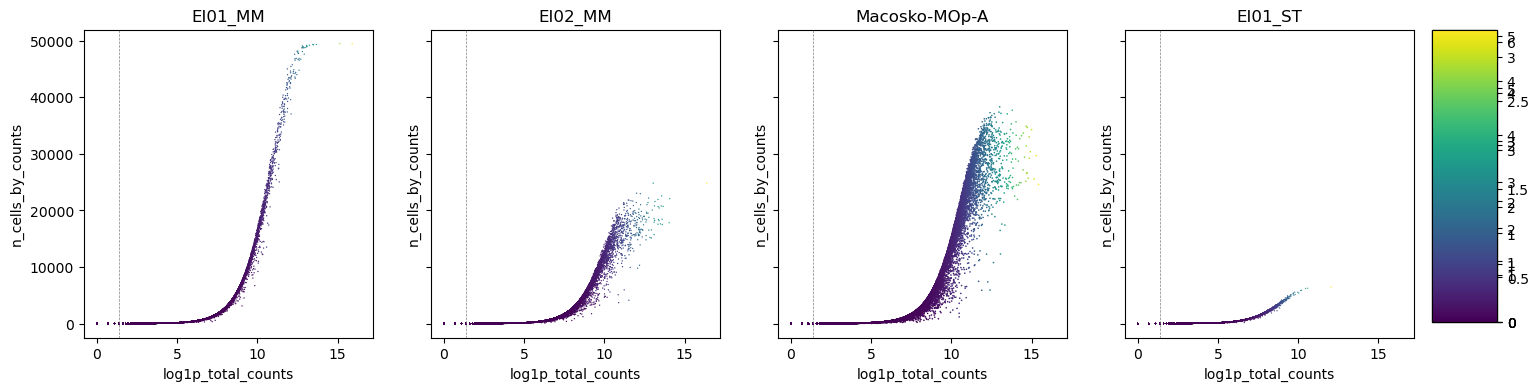

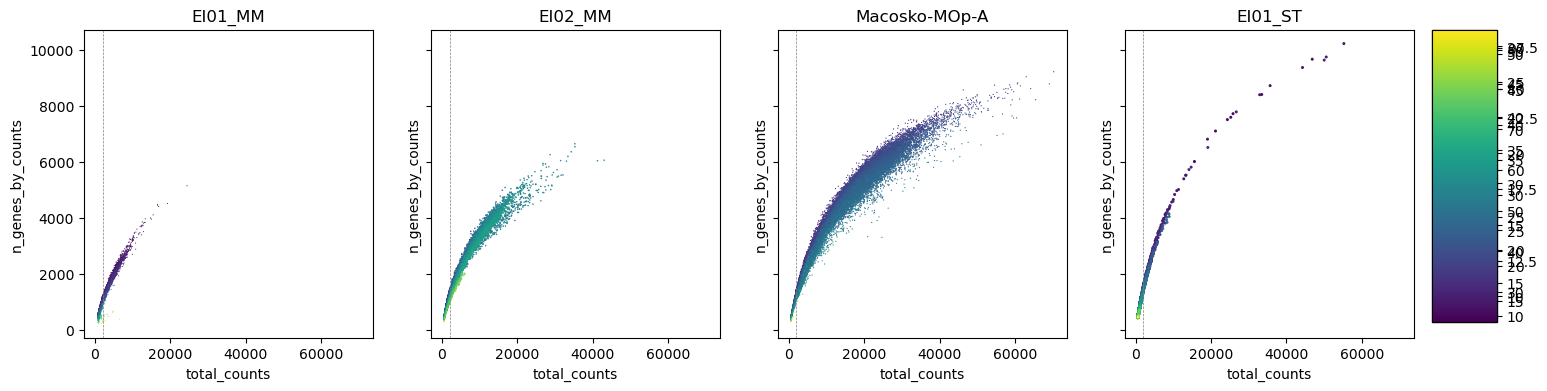

In [82]:
datasets = [ei01_mm, ei02_mm, macosko, ei01_st]
labels = ["EI01_MM", "EI02_MM", "Macosko-MOp-A", "EI01_ST"]

fig, axs = plt.subplots(1,4, figsize=(20,4), sharex=True, sharey=True)    
    
for i in range(4):
    data = datasets[i]
    label = labels[i]
    ax = axs[i]

    sc.pl.scatter(data, "log1p_total_counts", "n_cells_by_counts", color="log1p_mean_counts", 
                  legend_loc="none", ax=ax, show=False)

    ax.axvline(np.log1p(3), c="grey", ls="--", lw=0.5) # soft cut-off of at least 1000 counts per cell
    ax.set_title(label)
    # ax.text(np.log1p(3), 20000, "$\geq$3 genes per cell")

plt.subplots_adjust(right=0.79)
plt.show()

fig, axs = plt.subplots(1,4, figsize=(20,4), sharex=True, sharey=True)    
    
for i in range(4):
    data = datasets[i]
    label = labels[i]
    ax = axs[i]

    sc.pl.scatter(data, "total_counts", "n_genes_by_counts", color="pct_counts_in_top_50_genes", 
                  ax=ax, show=False)

    ax.axvline(2000, c="grey", ls="--", lw=0.5) # soft cut-off of at least 1000 counts per cell
    # ax.text(2000, 6000, "$\geq$2000 counts per cell")
    ax.set_title(label)

plt.subplots_adjust(right=0.79)
plt.show()


In [85]:
# number of cells that pass filtering steps

datasets = [ei01_mm, ei02_mm, macosko, ei01_st]
labels = ["EI01_MM", "EI02_MM", "Macosko-MOp-A", "EI01_ST"]

for i in range(4):
    data = datasets[i]
    label = labels[i]

    print(label.upper())

    # number of cells w/ total gene counts > 2000
    cells_pass = sum(data.obs["total_counts"]>2000)
    print(f"{cells_pass}/{data.n_obs} cells pass ({cells_pass/data.n_obs * 100:.2f}%)")

    # number of genes w/ total cell counts > 3
    genes_pass = sum(data.var["total_counts"]>3)
    print(f"{genes_pass}/{data.n_vars} genes pass ({genes_pass/data.n_vars * 100:.2f}%)")

    print("\n")




EI01_MM
15293/49479 cells pass (30.91%)
21652/32285 genes pass (67.07%)


EI02_MM
17885/24825 cells pass (72.04%)
23508/32285 genes pass (72.81%)


MACOSKO-MOP-A
37301/39530 cells pass (94.36%)
19066/21899 genes pass (87.06%)


EI01_ST
905/6482 cells pass (13.96%)
21654/38437 genes pass (56.34%)




In [86]:
datasets = [ei01_mm, ei02_mm, macosko, ei01_st]
labels = ["EI01_MM", "EI02_MM", "Macosko-MOp-A", "EI01_ST"]

for i in range(4):
    data = datasets[i]
    label = labels[i]

    sc.pp.scrublet(data)
    print(label.upper())
    print(f"Number of predicted doublets: {sum(data.obs["predicted_doublet"])}")
    print("\n")

/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


EI01_MM
Number of predicted doublets: 0


EI02_MM
Number of predicted doublets: 1214


MACOSKO-MOP-A
Number of predicted doublets: 865




/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


EI01_ST
Number of predicted doublets: 0


